In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
import ps_1loop_jax
from ps_1loop_jax.params import Params, BiasParams, CtrParams, StochParams

In [4]:
model = ps_1loop_jax.PowerSpectrum1LoopEPT(do_irres=True)

In [5]:
## input linear matter power spectrum
d = np.loadtxt('/Users/yosukekobayashi/codes/ps_1loop/example/data/pk_lin_planck18_fid_z0.txt')
pk_data = jnp.vstack((d[:,0], d[:,1]))

## other model parameters
params = Params(
    f=0.578,
    h=0.6736,
    bias=BiasParams(b1=2.0, b2=-1.0, bG2=0.1, bGamma3=-0.1),
    ctr=CtrParams(c0=5.0, c2=15.0, c4=-5.0, cfog=100.0),
    stoch=StochParams(P_shot=0.0, a0=0.0, a2=0.0),
    k_nl=0.45,
    ndens=3e-4
)

In [8]:
## Output P(k,mu) as jax.numpy array of shape (len(k), len(mu))
k = jnp.linspace(1e-3,0.3,100)
mu = jnp.linspace(0.,1.,11)
%time pkmu = model.get_pkmu(k, mu, pk_data, params)

CPU times: user 152 ms, sys: 17.8 ms, total: 170 ms
Wall time: 53.2 ms


## Redshift-space multiples (only $\ell = 0, 2, 4$ are supported)

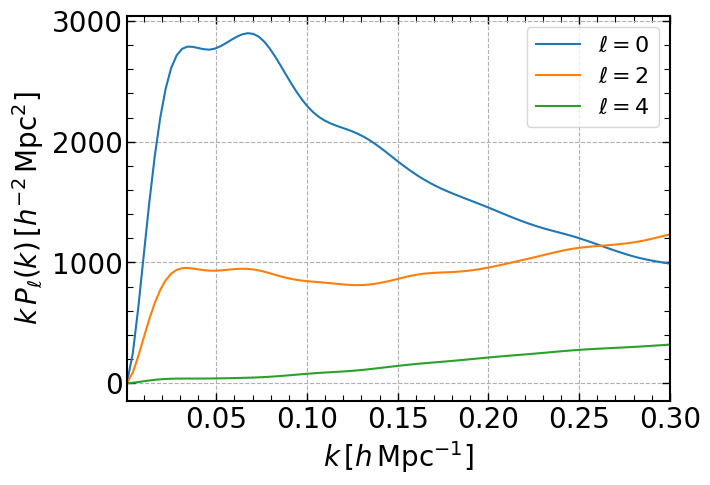

In [9]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = jnp.linspace(1e-3, 0.3, 100)
for l in [0,2,4]:
    pkl = model.get_pk_ell(k, l, pk_data, params)
    ax.plot(k, k * pkl, ls='-', label=r'$\ell = %s$' % (l))
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16)
    plt.grid(linestyle='--')

## Alcock-Pacynski effect

In [11]:
# AP parameters, depending on the reference cosmology and redshift
alpha_perp = 1.01
alpha_para = 1.0
l = 0

%time pkl_AP = model.get_pk_ell_ref(k, l, alpha_perp, alpha_para, pk_data, params)

CPU times: user 155 ms, sys: 20.9 ms, total: 176 ms
Wall time: 60.1 ms


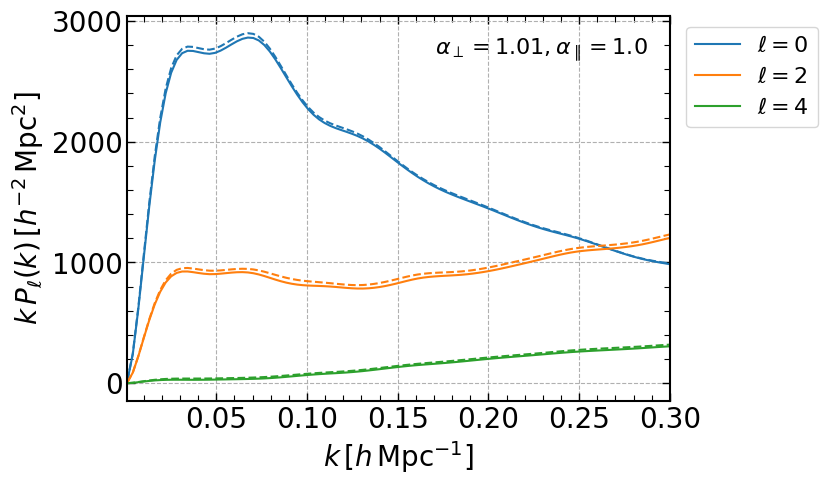

In [12]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

# AP parameters, depending on the reference cosmology and redshift
alpha_perp = 1.01
alpha_para = 1.

k = jnp.linspace(1e-3, 0.3, 100)
for i, l in enumerate([0,2,4]):
    pkl = model.get_pk_ell(k, l, pk_data, params)
    pkl_AP = model.get_pk_ell_ref(k, l, alpha_perp, alpha_para, pk_data, params)
    ax.plot(k, k * pkl_AP, ls='-', c=color[i], label=r'$\ell = %s$' % (l))
    ax.plot(k, k * pkl, ls='--', c=color[i], )

ax.text(0.96, 0.9, r'$\alpha_\perp=%s, \alpha_\parallel=%s$' % (alpha_perp, alpha_para), fontsize=16, transform=ax.transAxes, ha='right')
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')